# 05. Business Impact, Risk Tiering & Retention Strategies
## Banking Customer Churn Analytics

### Objectives
1. Segment customers into actionable Churn Risk Tiers (**High**, **Medium**, **Low**).
2. Calculate total deposit balances and customer lifetime value at risk ($).
3. Simulate proactive retention campaign ROI (cost vs saved value).
4. Review targeted strategic retention playbooks.


In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, os.path.abspath(".."))
from src.feature_engineering import BankFeatureEngineer
from src.modeling import BankChurnModeler
from src.business_insights import BankBusinessInsights

sns.set_theme(style="whitegrid")
df = pd.read_csv("../data/processed/bank_customer_churn_clean.csv")
fe = BankFeatureEngineer()
df_featured = fe.create_features(df)

X_train, X_test, y_train, y_test, _ = fe.prepare_train_test_data(df)
modeler = BankChurnModeler()
modeler.train_and_cross_validate(X_train, y_train)
champion = modeler.tune_champion_hyperparameters(X_train, y_train)

drop_cols = ["RowNumber", "CustomerId", "Surname", "Exited"]
all_X = df_featured.drop(columns=[c for c in drop_cols if c in df_featured.columns])
churn_probs = champion.predict_proba(all_X)[:, 1]


[Modeler] Running 5-Fold Stratified Cross-Validation on 3 candidate models...


  [OK] Logistic Regression    | ROC-AUC: 0.8483 (+/-0.0129) | PR-AUC: 0.6561 | F1: 0.5828


  [OK] Random Forest          | ROC-AUC: 0.8544 (+/-0.0101) | PR-AUC: 0.6700 | F1: 0.6119


  [OK] Gradient Boosting      | ROC-AUC: 0.8530 (+/-0.0125) | PR-AUC: 0.6851 | F1: 0.6106
[Modeler] Champion model selected: 'Random Forest' (ROC-AUC: 0.8544)
[Modeler] Fine-tuning champion Gradient Boosting model with GridSearchCV...


[Modeler] Best Hyperparameters: {'classifier__l2_regularization': 1.0, 'classifier__learning_rate': 0.05, 'classifier__max_depth': 5, 'classifier__max_iter': 150, 'classifier__min_samples_leaf': 25}
[Modeler] Best CV ROC-AUC: 0.8603


## 1. Assign Risk Tiers & Quantify Revenue at Risk

In [2]:
insights = BankBusinessInsights(high_risk_cutoff=0.65, medium_risk_cutoff=0.35)
df_scored = insights.assign_risk_tiers(df_featured, churn_probs)

tier_summary = insights.calculate_tier_financial_summary(df_scored)
tier_summary


,RiskTier,Total_Customers,Avg_Churn_Probability,Total_Balance_At_Risk,Avg_Balance,Total_Annual_Value_At_Risk,Avg_Age,Inactive_Rate,Pct_Total_Customers
0,High Risk,1911,83.8,1.765299e+08,92375.68,4657974.48,47.6,70.3,19.1
1,Medium Risk,2245,48.9,2.131741e+08,94955.05,3278108.58,40.4,49.5,22.4
2,Low Risk,5844,16.1,3.751549e+08,64194.88,2465297.62,35.5,41.0,58.4


## 2. Visualizing Financial Exposure Across Risk Tiers

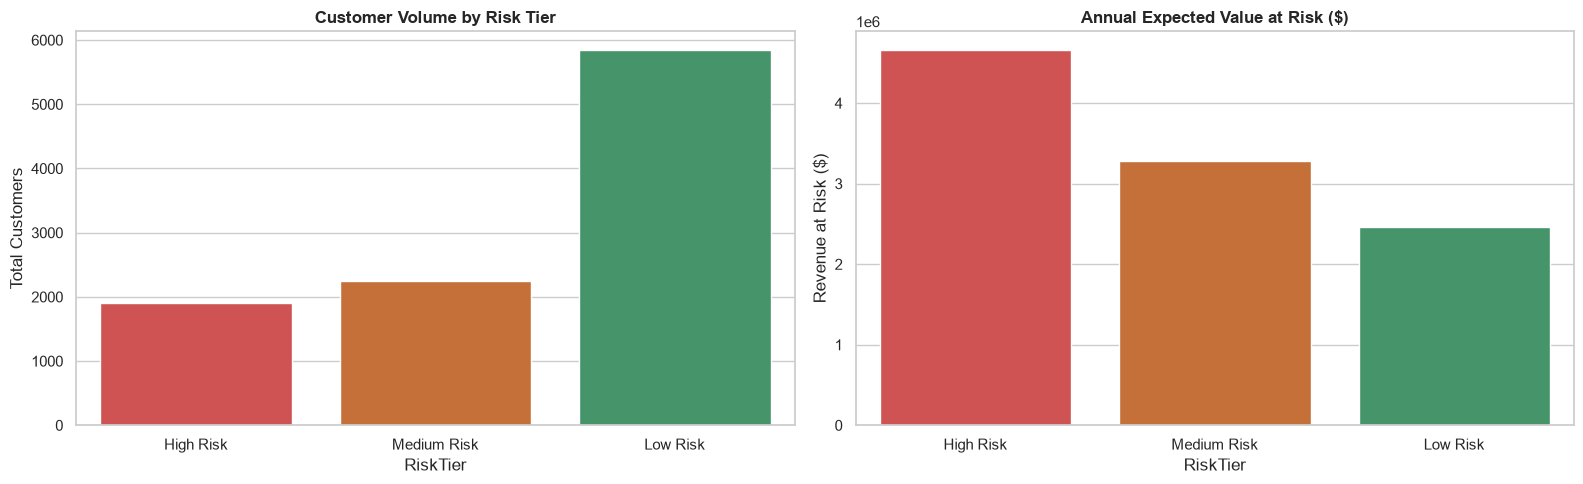

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(16, 5))
palette = ["#E53E3E", "#DD6B20", "#38A169"]

sns.barplot(data=tier_summary, x="RiskTier", y="Total_Customers", hue="RiskTier", palette=palette, legend=False, ax=ax[0])
ax[0].set_title("Customer Volume by Risk Tier", fontweight="bold")
ax[0].set_ylabel("Total Customers")

sns.barplot(data=tier_summary, x="RiskTier", y="Total_Annual_Value_At_Risk", hue="RiskTier", palette=palette, legend=False, ax=ax[1])
ax[1].set_title("Annual Expected Value at Risk ($)", fontweight="bold")
ax[1].set_ylabel("Revenue at Risk ($)")

plt.tight_layout()
plt.show()


## 3. Retention Campaign ROI Simulator

In [4]:
sim_results = insights.simulate_retention_campaign(
    df_scored,
    target_tiers=["High Risk", "Medium Risk"],
    intervention_cost_per_customer=120.0,
    campaign_save_rate=0.28
)

print("--- PROACTIVE RETENTION CAMPAIGN FINANCIAL MODEL ---")
for k, v in sim_results.items():
    print(f"- {k:<30}: {v}")


--- PROACTIVE RETENTION CAMPAIGN FINANCIAL MODEL ---
- targeted_tiers                : ['High Risk', 'Medium Risk']
- targeted_customers_count      : 4156
- intervention_cost_per_customer: 120.0
- total_campaign_cost           : 498720.0
- assumed_save_rate             : 0.28
- expected_customers_saved      : 756
- gross_annual_value_saved      : 2222103.26
- net_financial_benefit         : 1723383.26
- retention_roi_percent         : 345.6


## 4. Strategic Retention Playbooks

In [5]:
playbooks = insights.generate_strategic_playbooks()
for idx, p in enumerate(playbooks, 1):
    print(f"\n{'='*70}\n[PLAYBOOK {idx}] Segment: {p['Segment']}\n{'='*70}")
    print(f"- Core Drivers:    {p['Driver']}")
    print(f"- Strategic Action:{p['Action_Plan']}")
    print(f"- Projected Impact:{p['Expected_Impact']}")



[PLAYBOOK 1] Segment: German High-Deposit Accounts (Age 45-60)
- Core Drivers:    Competitive wealth alternatives, high account balances, zero-fee expectations
- Strategic Action:Deploy dedicated Relationship Managers; offer preferential 0.50% APY savings booster and wealth advisory consultation.
- Projected Impact:18-25% reduction in high-balance deposit attrition.

[PLAYBOOK 2] Segment: Multi-Product Inactive Customers (3+ Products)
- Core Drivers:    Product fragmentation, orphaned cards, lack of primary banking engagement
- Strategic Action:Launch automated digital product consolidation workflow with fee-rebate incentive upon 3 monthly mobile logins.
- Projected Impact:30% increase in digital engagement; 15% reduction in product closure.

[PLAYBOOK 3] Segment: Mature Age Cohort (Age 50-65) with High Balances
- Core Drivers:    Retirement asset reallocation and competitive rate shopping
- Strategic Action:Proactive outreach by Senior Wealth Planners with tailored fixed-income and e